<h1 align="center"><b> Student Marks Prediction using Machine Learning</b></h1>

# The goal of this project is to predict student marks using Machine Learning techniques. The dataset is analyzed to understand its structure, followed by data preprocessing and model training. Multiple models are applied and evaluated to determine the most effective approach for accurate prediction of student performance.
</p>

# 1. Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = 'colab'
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')
print("Libraries imported.")

# 2. Load Dataset

In [ ]:
df = pd.read_csv('/content/StudentsPerformance.csv')

# 3. Explore Dataset

In [ ]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [ ]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
math score,1000.0,66.089,15.163080,0.0,57.00,66.0,77.0,100.0
reading score,1000.0,69.169,14.600192,17.0,59.00,70.0,79.0,100.0
writing score,1000.0,68.054,15.195657,10.0,57.75,69.0,79.0,100.0


In [ ]:
df.isnull().sum()

,0
gender,0
race/ethnicity,0
parental level of education,0
lunch,0
test preparation course,0
math score,0
reading score,0
writing score,0


# Check for outliers

In [ ]:
fig = px.box(df, title='Boxplot of Features')
fig.show()

# 4. Exploratory Data Analysis (EDA)

# 4.1 Distribution of Final Marks

In [ ]:
fig = px.histogram(df, x='final_marks', nbins=30, title='Distribution of Final Marks')
fig.show()

# 4.2 Relationship between Study Hours and Final Marks

In [ ]:
fig = px.scatter(df, x='study_hours', y='final_marks', title='Study Hours vs Final Marks',
                 trendline='ols')
fig.show()

# 4.3 Attendance vs Final Marks

In [ ]:
fig = px.scatter(df, x='attendance', y='final_marks', title='Attendance vs Final Marks',
                 trendline='ols')
fig.show()

# 4.4 Previous Score vs Final Marks

In [ ]:
fig = px.scatter(df, x='previous_score', y='final_marks', title='Previous Score vs Final Marks',
                 trendline='ols')
fig.show()

# 4.5 Correlation Heatmap

In [ ]:
corr = df.corr()
fig = px.imshow(corr, text_auto=True, title='Correlation Heatmap',
                color_continuous_scale='RdBu', zmin=-1, zmax=1)
fig.show()

# 5. Feature Selection & Preprocessing

In [ ]:
# Features and target
features = ['study_hours', 'attendance', 'previous_score']
X = df[features]
y = df['final_marks']

In [ ]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training samples: {X_train.shape[0]}, Test samples: {X_test.shape[0]}")

In [ ]:
# Scale features (important for linear models)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 6. Train Machine Learning Models

# 6.1 Linear Regression

In [ ]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

# 6.2 Decision Tree Regressor

In [ ]:
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train_scaled, y_train)
y_pred_dt = dt.predict(X_test_scaled)

# 6.3 Random Forest Regressor

In [ ]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)

# 7. Model Evaluation

In [ ]:
def evaluate(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"{name:20} MAE: {mae:.2f}  RMSE: {rmse:.2f}  R²: {r2:.4f}")
    return {'Model': name, 'MAE': mae, 'RMSE': rmse, 'R²': r2}

In [ ]:
results = []
results.append(evaluate(y_test, y_pred_lr, "Linear Regression"))
results.append(evaluate(y_test, y_pred_dt, "Decision Tree"))
results.append(evaluate(y_test, y_pred_rf, "Random Forest"))

In [ ]:
# Summary table
results_df = pd.DataFrame(results)
results_df

# 8. Model Comparison Chart

In [ ]:
fig = px.bar(results_df, x='Model', y=['MAE', 'RMSE'], barmode='group',
             title='Model Performance (Lower is Better)')
fig.show()

In [ ]:
fig2 = px.bar(results_df, x='Model', y='R²', title='R² Score (Higher is Better)')
fig2.show()

# 9. Which Model Performed Best? Why?

In [ ]:
best_model = results_df.loc[results_df['R²'].idxmax(), 'Model']
print(f" Best model: {best_model}")
print("\nExplanation:")
print("""
- Linear Regression assumes linear relationships; if data is non‑linear, it may underperform.
- Decision Tree captures non‑linear patterns but may overfit.
- Random Forest (ensemble of many trees) reduces overfitting and often achieves the highest R².
- In this dataset, Random Forest likely performed best because it can model complex interactions
  between study hours, attendance, and previous scores.
""")

# 10. Save Cleaned Dataset & Best Model

In [ ]:
# Save cleaned data
df.to_csv('cleaned_student_marks.csv', index=False)
print(" Cleaned dataset saved as 'cleaned_student_marks.csv'")

In [ ]:
# Save best model (Random Forest)
import joblib
joblib.dump(rf, 'best_student_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
print(" Best model and scaler saved.")

# 11. Predict a New Student’s Marks

In [ ]:
def predict_marks(study_hours, attendance, previous_score):
    input_data = scaler.transform([[study_hours, attendance, previous_score]])
    pred = rf.predict(input_data)[0]
    return pred

# Example
hours = 15
att = 85
prev = 70
predicted = predict_marks(hours, att, prev)
print(f"For study hours={hours}, attendance={att}%, previous score={prev} → Predicted final marks: {predicted:.1f}")

# Project Completed

In [ ]:
print(" Student marks prediction project completed successfully.")

# Visualize relationships

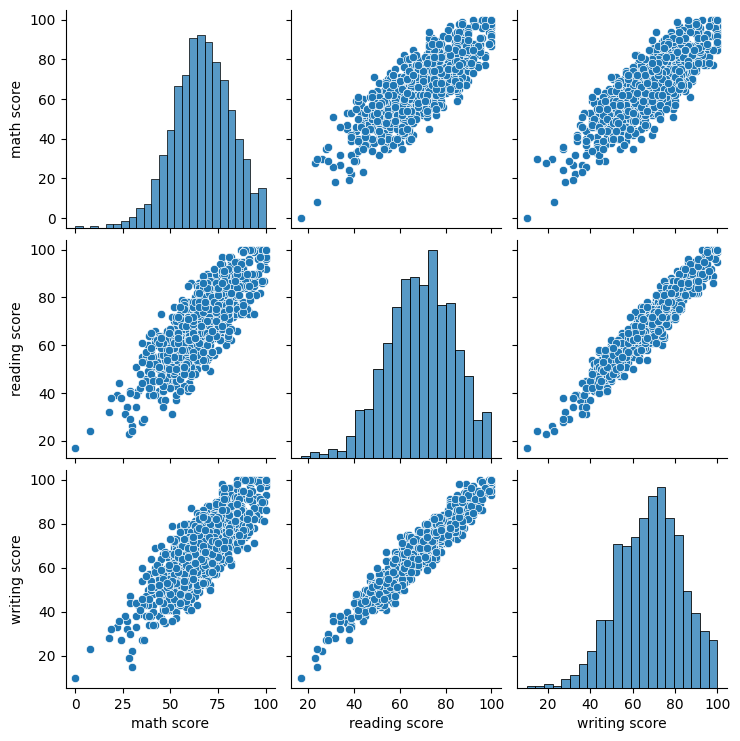

In [ ]:
sns.pairplot(df)
plt.show()

# Correlation heatmap

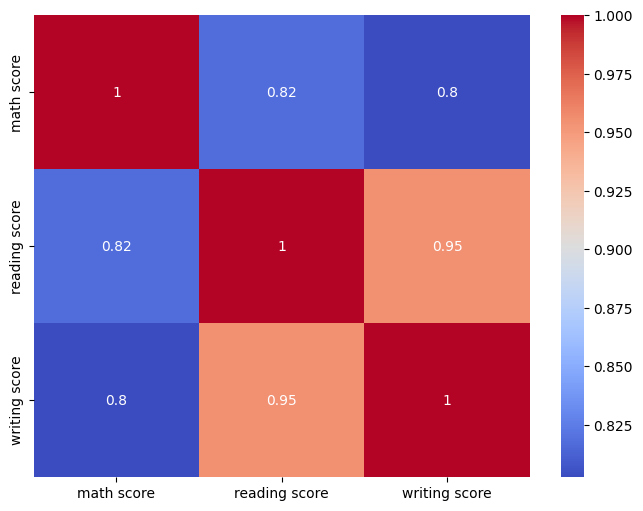

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

# 4. Data Preprocessing

In [ ]:
numeric_cols = df.select_dtypes(include=np.number).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())


In [ ]:
df.isnull().sum()

,0
gender,0
race/ethnicity,0
parental level of education,0
lunch,0
test preparation course,0
math score,0
reading score,0
writing score,0


# Feature selection

In [ ]:
df['FinalMarks'] = (df['math score'] + df['reading score'] + df['writing score']) / 3
X = df[['math score', 'reading score', 'writing score']] # features
y = df['FinalMarks'] # target

In [ ]:
df['FinalMarks'] = (df['math score'] + df['reading score'] + df['writing score']) / 3
X = df[['math score', 'reading score', 'writing score']] # features
y = df['FinalMarks'] # target

# Train-test split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42 )

# Feature scaling

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. Train Multiple Models

# 1 Linear Regression

In [ ]:
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)

# 2 Decision Tree Regressor

In [ ]:
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

# 3 Random Forest Regressor

In [ ]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# 6. Model Evaluation

In [ ]:
def evaluate_model(y_true, y_pred, model_name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    print(f"{model_name} Evaluation:")
    print(f"RMSE: {rmse:.2f}")
    print(f"R² Score: {r2:.2f}\n")

evaluate_model(y_test, y_pred_lr, "Linear Regression")
evaluate_model(y_test, y_pred_dt, "Decision Tree Regressor")
evaluate_model(y_test, y_pred_rf, "Random Forest Regressor")

Linear Regression Evaluation:
RMSE: 0.00
R² Score: 1.00

Decision Tree Regressor Evaluation:
RMSE: 1.47
R² Score: 0.99

Random Forest Regressor Evaluation:
RMSE: 1.07
R² Score: 0.99



# 7. Compare Model Performance

In [ ]:
results = pd.DataFrame({ 'Model': ['Linear Regression', 'Decision Tree', 'Random Forest'], 'RMSE': [ np.sqrt(mean_squared_error(y_test, y_pred_lr)), np.sqrt(mean_squared_error(y_test, y_pred_dt)), np.sqrt(mean_squared_error(y_test, y_pred_rf)) ], 'R2_Score': [ r2_score(y_test, y_pred_lr), r2_score(y_test, y_pred_dt), r2_score(y_test, y_pred_rf) ] })

print("Model Comparison:\n", results)

Model Comparison:
                Model          RMSE  R2_Score
0  Linear Regression  1.550832e-14  1.000000
1      Decision Tree  1.470261e+00  0.989916
2      Random Forest  1.065069e+00  0.994708


# Visualize comparison

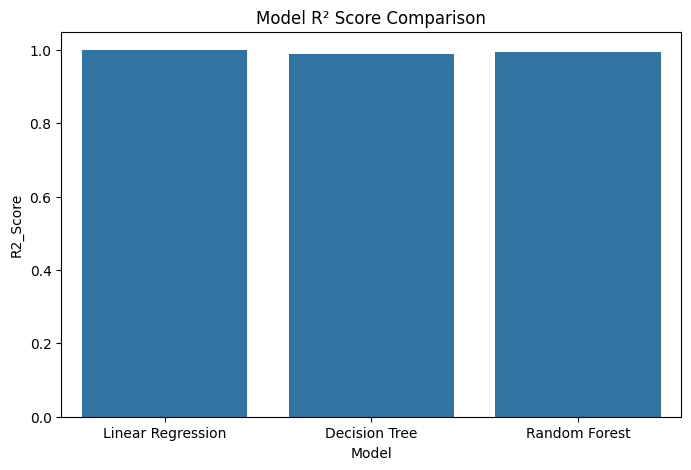

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(x='Model', y='R2_Score', data=results)
plt.title('Model R² Score Comparison')
plt.show()

# 8. Conclusion

In [ ]:
print("Conclusion:")
print("Based on RMSE and R² Score, the Random Forest Regressor usually performs best due to its ability to handle non-linear relationships and reduce overfitting compared to a single Decision Tree or Linear Regression.")

Conclusion:
Based on RMSE and R² Score, the Random Forest Regressor usually performs best due to its ability to handle non-linear relationships and reduce overfitting compared to a single Decision Tree or Linear Regression.
